In [1]:
import numpy as np 
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import math
import torch
import gpytorch
import tqdm.notebook as tqdm
from sklearn.model_selection import train_test_split

# torch.set_default_dtype(torch.double)

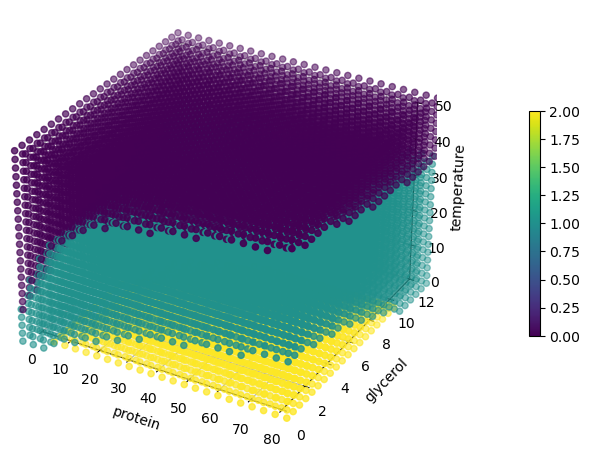

In [2]:
boundary_dataset = xr.load_dataset('250610-extrap_expand_dataset.nc')

fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

ax = ax
mappable = ax.scatter(
    boundary_dataset["composition"].sel(component='protein').values,
    boundary_dataset["composition"].sel(component='glycerol').values,
    boundary_dataset["composition"].sel(component='temperature').values,
    c=boundary_dataset.labels.values
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [3]:
X = boundary_dataset["composition"].values.T
y = boundary_dataset.labels.values 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y) 

In [4]:
from pytorch_tabnet.tab_model import TabNetClassifier

# Ensure all inputs are the correct dtype
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('int64')
y_test = y_test.astype('int64')

clf = TabNetClassifier()

clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.74203 | val_0_accuracy: 0.40818 |  0:00:00s
epoch 1  | loss: 0.27185 | val_0_accuracy: 0.49699 |  0:00:01s
epoch 2  | loss: 0.20823 | val_0_accuracy: 0.49583 |  0:00:02s
epoch 3  | loss: 0.19096 | val_0_accuracy: 0.52453 |  0:00:02s
epoch 4  | loss: 0.17632 | val_0_accuracy: 0.5796  |  0:00:03s
epoch 5  | loss: 0.17637 | val_0_accuracy: 0.61179 |  0:00:03s
epoch 6  | loss: 0.17372 | val_0_accuracy: 0.61877 |  0:00:04s
epoch 7  | loss: 0.17481 | val_0_accuracy: 0.66395 |  0:00:05s
epoch 8  | loss: 0.16734 | val_0_accuracy: 0.7039  |  0:00:05s
epoch 9  | loss: 0.16733 | val_0_accuracy: 0.72406 |  0:00:06s
epoch 10 | loss: 0.16023 | val_0_accuracy: 0.75082 |  0:00:07s
epoch 11 | loss: 0.1631  | val_0_accuracy: 0.77739 |  0:00:07s
epoch 12 | loss: 0.17242 | val_0_accuracy: 0.77526 |  0:00:08s
epoch 13 | loss: 0.16281 | val_0_accuracy: 0.81385 |  0:00:09s
epoch 14 | loss: 0.16708 | val_0_accuracy: 0.80667 |  0:00:09s
epoch 15 | loss: 0.16087 | val_0_accuracy: 0.82277 |  0

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


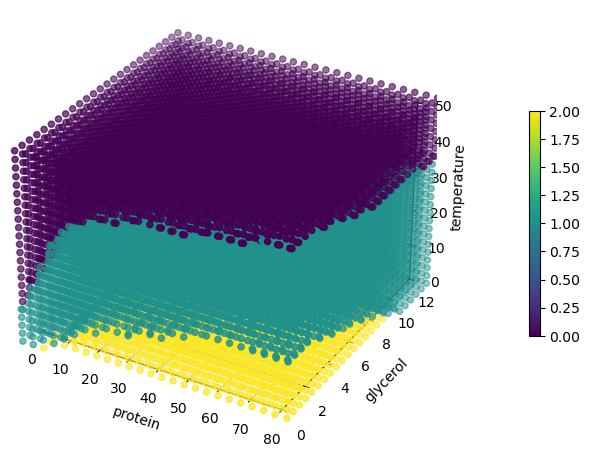

In [5]:
fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

tabnet_labels = clf.predict(X) 
mappable = ax.scatter(
    boundary_dataset["composition"].sel(component='protein').values,
    boundary_dataset["composition"].sel(component='glycerol').values,
    boundary_dataset["composition"].sel(component='temperature').values,
    c=tabnet_labels
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [6]:
i = 0
ds = xr.load_dataset('./results/line_samples/run_%d/ds.nc'%(i+1)) 

In [7]:
from torch.nn.functional import softmax

clf.network.eval()
with torch.no_grad():
    Xt = torch.from_numpy(ds.design_space_grid.values).to(torch.float32)
    logits = clf.network(Xt)[0]
probs = softmax(logits, dim=1).numpy()
eps = 1e-12
entropy = -np.sum(probs * np.log(probs + eps), axis=1)

In [8]:
import torch
import torch.nn.functional as F

def compute_entropy_gradient(x, clf):
    """
    x: torch.Tensor of shape (d,) or (1, d), requires_grad=True
    clf: classifier object with .network
    """
    clf.network.eval()
    
    if x.ndim == 1:
        x = x.unsqueeze(0)  # shape (1, d)

    x = x.clone().detach().requires_grad_(True)  # Ensure it's a leaf with grad tracking

    logits = clf.network(x.to(torch.float32))[0]  # shape (1, num_classes)
    probs = F.softmax(logits, dim=1)  # shape (1, num_classes)
    
    # Compute entropy 
    entropy = -torch.sum(probs * torch.log(probs + 1e-12), dim=1)  # shape (1,)
    
    # Compute gradient of entropy w.r.t. x
    entropy.backward()

    grad = x.grad.detach().clone()  # shape (1, d)
    return grad.squeeze(0), entropy.detach().item()

entropy, grad = [], []
for xt in Xt:
    g, e = compute_entropy_gradient(xt, clf)
    entropy.append(e)
    grad.append(g)
entropy = np.asarray(entropy)
grad = torch.stack(grad, dim=0)

/var/folders/rp/7vyn7s1x0nnbgmjhr2bvs_1c002hph/T/ipykernel_61745/661755202.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  U = U/(norm+1e-3)
/var/folders/rp/7vyn7s1x0nnbgmjhr2bvs_1c002hph/T/ipykernel_61745/661755202.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  V = V/(norm+1e-3)
/var/folders/rp/7vyn7s1x0nnbgmjhr2bvs_1c002hph/T/ipykernel_61745/661755202.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  W = W/(norm+1e-3)


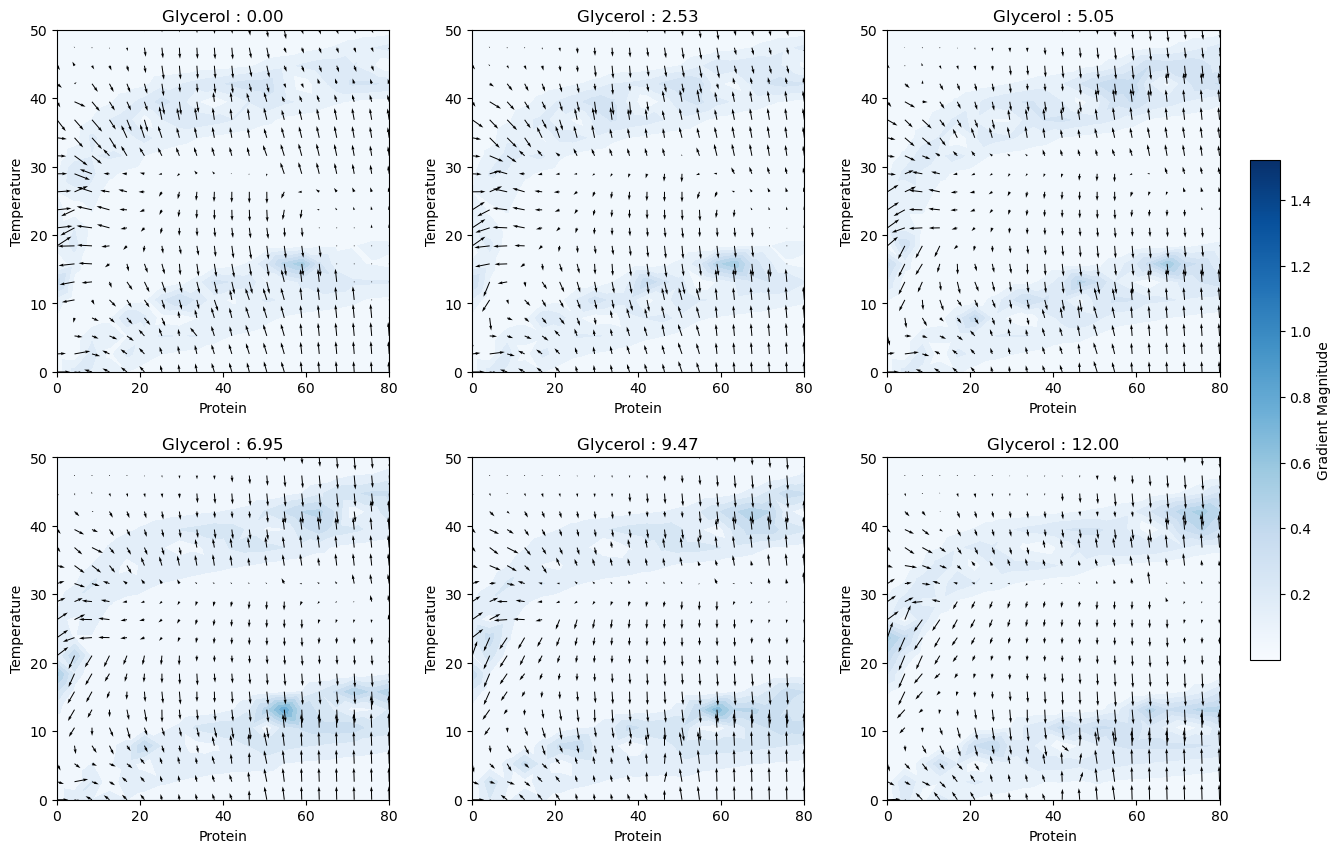

In [45]:
from matplotlib.colors import Normalize

U = grad[:,0]
V = grad[:,1]
W = grad[:,2]
# Normalize the arrows:
norm = torch.linalg.norm(grad, dim=1).numpy()
U = U/(norm+1e-3) 
V = V/(norm+1e-3)
W = W/(norm+1e-3)

fig, axs = plt.subplots(2,3, figsize=(5*3, 5*2))
fig.subplots_adjust(hspace=0.25, wspace=0.25)
axs = axs.flatten()
glycerol_levels = Xt[:,2].unique()
indices = torch.linspace(0, len(levels)-1, steps=6).round().long()
cmap = plt.get_cmap("Blues")
cnorm = Normalize(vmin=norm.min(), vmax=norm.max())
sm = ScalarMappable(norm=cnorm, cmap=cmap)
for i, level in enumerate(glycerol_levels[indices]):
    flags = np.isclose(Xt[:,2], glycerol_levels[i], atol=1/20)
    ax = axs[i]
    cf = ax.tricontourf(Xt[flags,0],
                   Xt[flags,1],
                   norm[flags],
                   cmap = cmap,
                   norm = cnorm
                )
    ax.quiver(Xt[flags,0], 
              Xt[flags,1], 
              U[flags], 
              W[flags], 
              units="width", 
              lw=5.0
            )
    ax.set_title(f"Glycerol : {level:.2f}")
    ax.set_xlabel("Protein")
    ax.set_ylabel("Temperature")
ax_cb = fig.add_axes([0.92, 0.25, 0.02, 0.5]) 
cbar = fig.colorbar(sm, cax=ax_cb, shrink=0.5, pad=0.15)
cbar.set_label("Gradient Magnitude")

plt.show()

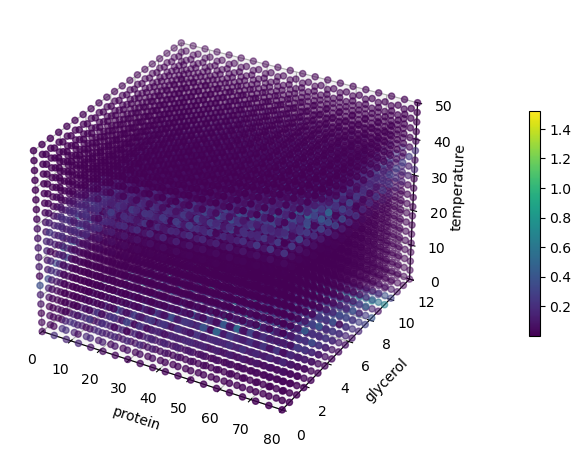

In [10]:
fig, ax  = plt.subplots(subplot_kw={"projection":'3d'})

mappable = ax.scatter(
    ds["design_space_grid"].sel(ds_dim='protein').values,
    ds["design_space_grid"].sel(ds_dim='glycerol').values,
    ds["design_space_grid"].sel(ds_dim='temperature').values,
    c=norm
)
ax.set_xlim(0, 80)
ax.set_ylim(0, 12)
ax.set_zlim(0, 50)
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
ax.set_xlabel("protein")
ax.set_ylabel("glycerol")
ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

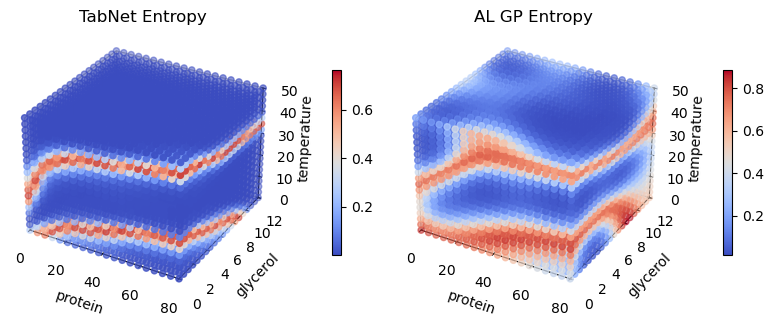

In [11]:
fig, axs  = plt.subplots(1,2, figsize=(4*2, 4), subplot_kw={"projection":'3d'})


axs[0].set_title("TabNet Entropy")
axs[1].set_title("AL GP Entropy")
for ax, f in zip(axs, [entropy, ds.phase_entropy.values]):
    mappable = ax.scatter(
        ds["design_space_grid"].sel(ds_dim='protein').values,
        ds["design_space_grid"].sel(ds_dim='glycerol').values,
        ds["design_space_grid"].sel(ds_dim='temperature').values,
        c=f,
        cmap="coolwarm"
    )
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 12)
    ax.set_zlim(0, 50)
    cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, pad=0.15)
    ax.set_xlabel("protein")
    ax.set_ylabel("glycerol")
    ax.set_zlabel("temperature", labelpad=-1)
plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import spearmanr 

corr, _ = spearmanr(entropy, ds.phase_entropy.values)
print("Spearman correlation:", corr)

Spearman correlation: 0.6932618288738362
